# Creating summary plots of empirical distributions from local data

In [2]:
bin_size = 0.001
seed = 42
model_conditions = {'drift_rate': 1.2, 'theta': 0.38, 'noise': 0.5}

In [3]:
import simulation

path = '/Users/braydenchien/Desktop/Enkavilab/DDM/1ms_trial_data.csv'
empirical_distributions = simulation.get_empirical_distributions(path, bin_size)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def _as_1d_float_array(x):
    if x is None:
        return np.array([], dtype=float)
    return np.asarray(x, dtype=float).ravel()

def _fix_lengths_per_key(fix_map):
    """
    fix_map: dict where keys are floats in [-4.0, 4.0] step 0.25
             and values are array-like (whose lengths we count).
    Returns (keys_sorted_float, lengths_per_key_as_float).
    """
    if not isinstance(fix_map, dict) or not fix_map:
        return np.array([], dtype=float), np.array([], dtype=float)
    # Sort keys numerically to keep the x-axis ordered
    keys = sorted(fix_map.keys(), key=float)
    lengths = [len(_as_1d_float_array(fix_map[k])) for k in keys]
    return np.array(keys, dtype=float), np.array(lengths, dtype=float)

def _set_sparse_xticks(ax, xs, every=4, rotation=0):
    """Show only every Nth tick to reduce clutter."""
    if xs.size == 0:
        return
    idx = np.arange(xs.size)
    show = (idx % every) == 0
    ax.set_xticks(xs[show])
    ax.set_xticklabels([f"{v:g}" for v in xs[show]], rotation=rotation)

def plot_empirical_distributions(ed, *, tick_every=4):
    """
    ed: dict with keys:
        - 'latencies': np.ndarray of floats
        - 'transitions': np.ndarray of floats
        - 'fixations': dict {1: dict{float_key: array}, 2: dict{float_key: array}}

    Creates a 2x2 figure:
      (1,1) histogram of ed['latencies']
      (1,2) histogram of ed['transitions']
      (2,1) bar chart: keys of fixations[1] on x, lengths of arrays as heights
      (2,2) bar chart: keys of fixations[2] on x, lengths of arrays as heights
    """
    latencies = _as_1d_float_array(ed.get('latencies', np.array([])))
    transitions = _as_1d_float_array(ed.get('transitions', np.array([])))

    fix = ed.get('fixations', {}) if isinstance(ed, dict) else {}
    fix1 = fix.get(1, {})
    fix2 = fix.get(2, {})

    keys1, lens1 = _fix_lengths_per_key(fix1)
    keys2, lens2 = _fix_lengths_per_key(fix2)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    ax11, ax12, ax21, ax22 = axes.ravel()

    # Top row: true histograms (continuous/binning)
    ax11.hist(latencies, bins=40)
    ax11.set_title("Latencies")
    ax11.set_xlabel("Latency")
    ax11.set_ylabel("Count")

    ax12.hist(transitions, bins=40)
    ax12.set_title("Transitions")
    ax12.set_xlabel("Transition value")
    ax12.set_ylabel("Count")

    # Bottom row: fixed-bin “histograms” → bar charts at the exact key values
    if keys1.size:
        # width smaller than the 0.25 spacing to leave a small gap
        ax21.bar(keys1, lens1, width=0.20, align='center')
        ax21.set_xlim(keys1.min() - 0.2, keys1.max() + 0.2)
        _set_sparse_xticks(ax21, keys1, every=tick_every, rotation=90)
    ax21.set_title("First Fixations: count per key")
    ax21.set_xlabel("Signed Value Difference")
    ax21.set_ylabel("Count (length of array)")

    if keys2.size:
        ax22.bar(keys2, lens2, width=0.20, align='center')
        ax22.set_xlim(keys2.min() - 0.2, keys2.max() + 0.2)
        _set_sparse_xticks(ax22, keys2, every=tick_every, rotation=90)
    ax22.set_title("Second Fixations: count per key")
    ax22.set_xlabel("Signed Value Difference")
    ax22.set_ylabel("Count (length of array)")

    fig.suptitle("Empirical Distributions", y=0.98)
    fig.tight_layout()
    return fig, axes

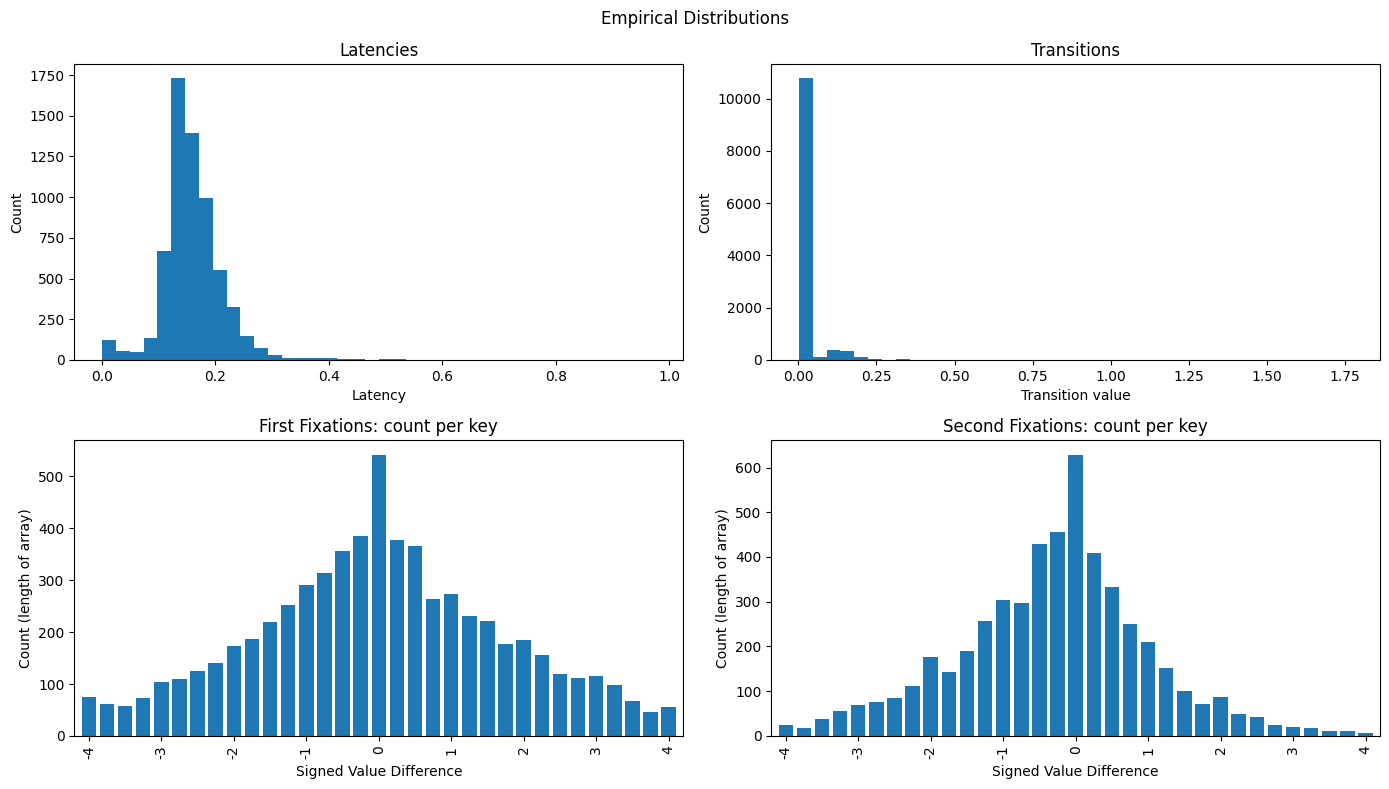

In [5]:
fig, axes = plot_empirical_distributions(empirical_distributions, tick_every=4)
plt.show()

# Creating summary plots of empirical distributions from Tavares project data

The original get empirical distributions is highly specialized for my intial exploration of data. No modifications were made to that part of the pipeline when it worked, but now, we need something more general. Several changes take place: 

- Takes in a DataFrame instead of a path
- Does not handle exclusions (aka, exclusions handled outside of empirical distributions)
- Fixations is already a numpy array and not a tuple encapsulated in string
- Lean DataFrame required including a fixations column, avgWTP_left, and avgWTP_right
- Generalize value_diffs

So the following workflow will:

1. Transform fixations using new `generate_fixations` function
2. Combine experimental and fixation data into one dataframe
3. Capture novel value diffs within `get_empirical_distributions`


## Transforming Fixations

First, we need a helper function to get from fixation location and duration into fixation location and fixation start and end times. I'll need to rename the existing helper functions in /Users/braydenchien/Desktop/Enkavilab/PyDDM/pyddm/preprocessing.

In [6]:
import pandas as pd

def fix_dur_to_fix_start_and_end(
    df: pd.DataFrame,
    fix_dur_col_name: str,
    trial_col_name: str,
    subject_col_name: str,
    start_col_name: str = "fix_start",
    end_col_name: str = "fix_end",
):
    """
    Compute inclusive start/end indices per (subject, trial).

    For each (subject, trial):
      - first fixation starts at 0 and ends at duration-1
      - next starts at prev_end + 1
    """
    if fix_dur_col_name not in df.columns:
        raise KeyError(f"Missing duration column: {fix_dur_col_name!r}")
    if trial_col_name not in df.columns:
        raise KeyError(f"Missing trial column: {trial_col_name!r}")
    if subject_col_name not in df.columns:
        raise KeyError(f"Missing subject column: {subject_col_name!r}")

    # Work on a copy
    work = df.copy()

    # Validate and drop zero/negative
    durations_all = pd.to_numeric(work[fix_dur_col_name], errors="coerce")
    if durations_all.isna().any():
        bad = work.index[durations_all.isna()].tolist()
        raise ValueError(
            f"{fix_dur_col_name!r} contains non-numeric values at indices {bad[:5]}..."
        )

    mask = durations_all > 0
    work = work.loc[mask].copy()
    durations = pd.to_numeric(work[fix_dur_col_name], errors="coerce")
    if (durations < 0).any():
        neg_idx = work.index[durations < 0].tolist()
        raise ValueError(
            f"{fix_dur_col_name!r} contains negative values at indices {neg_idx[:5]}..."
        )

    # Group by BOTH subject and trial
    keys = [work[subject_col_name], work[trial_col_name]]

    # starts = cumsum(shifted durations) within each (subject, trial)
    starts = (
        durations.groupby(keys)
        .apply(lambda s: s.shift(fill_value=0).cumsum())
        .reset_index(level=[0,1], drop=True)
    )

    ends = starts + durations - 1  # inclusive end

    work[start_col_name] = starts.astype("int64")
    work[end_col_name]   = ends.astype("int64")

    return work


In [7]:
import os

parent_dir = '/Users/braydenchien/Desktop/Enkavilab/aDDM-Toolbox/addm_toolbox/data'
fixations_path = os.path.join(parent_dir, 'fixations.csv')

fixations_df = pd.read_csv(fixations_path)

It turns out that there are several fixations with times of 0. I didn't yet investigate why this appears in data, nor how this actually happened (I'm guessing some sort of floor operator on a quick glance, all during saccades, which are encoded 3). For now, they are completely removed from the fixation numpy array.

In [8]:
fixations_df[fixations_df['fix_time'] == 0].head()

,parcode,trial,fix_item,fix_time
23519,2,935,3,0.0
38394,4,528,3,0.0
44428,5,115,3,0.0
46883,5,462,3,0.0
57874,6,875,3,0.0


In [9]:
reformatted_df = fix_dur_to_fix_start_and_end(fixations_df, 'fix_time', 'trial', 'parcode')

Now using `derasterize_functions`

In [10]:
from pyddm.preprocessing.dataset import derasterize_data

derasterized_df = derasterize_data(reformatted_df, "parcode", "trial", loc_col="fix_item")

   parcode  trial  fix_item  fix_time  fix_start  fix_end
0        0      0         3     176.0          0      175
1        0      0         0      42.0        176      217
2        0      0         1     188.0        218      405
3        0      0         0      72.0        406      477
4        0      0         2     582.0        478     1059
5        0      0         0      68.0       1060     1127
6        0      0         1     834.0       1128     1961


## Combining data

In [11]:
exp_path = os.path.join(parent_dir, 'expdata.csv')

exp_df = pd.read_csv(exp_path)

Why is valid an empty column in the csv?? Anyways, I first verify that dataframes are the same shape.

In [12]:
print(exp_df.shape)
print(derasterized_df.shape)

(31854, 7)
(31854, 4)


In [13]:
total_df = pd.concat([exp_df, derasterized_df], axis=1)
total_df = total_df.loc[:, ~total_df.columns.duplicated()]
total_df = total_df.drop(columns=["valid"])
total_df.shape

(31854, 8)

In [14]:
total_df.head()

,parcode,trial,rt,choice,item_left,item_right,fix_item,fix_sequence
0,0,0,1962.0,-1,15,0,3,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ..."
1,0,1,2899.0,-1,-10,-15,3,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ..."
2,0,2,1631.0,1,-15,15,3,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ..."
3,0,3,3203.0,-1,5,10,3,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ..."
4,0,4,1181.0,1,-10,10,3,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ..."


In [15]:
print(max(total_df['trial'])*max(total_df['parcode']))
print(total_df.shape[0])

32184
31854


Checking that response times match the lengths of fixation sequences.

In [16]:
error = []

for i in range(total_df.shape[0]):
    if not total_df["rt"][i]==total_df['fix_sequence'][i].shape[0]:
        error.append(i)

len(error)

0

Correct item values for left and right

In [17]:
from addm_toolbox.util import convert_item_values

total_df['item_left'] = convert_item_values(total_df['item_left']).astype(int)
total_df['item_right'] = convert_item_values(total_df['item_right']).astype(int)

total_df.head()

,parcode,trial,rt,choice,item_left,item_right,fix_item,fix_sequence
0,0,0,1962.0,-1,0,3,3,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ..."
1,0,1,2899.0,-1,1,0,3,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ..."
2,0,2,1631.0,1,0,0,3,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ..."
3,0,3,3203.0,-1,2,1,3,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ..."
4,0,4,1181.0,1,1,1,3,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ..."


In [18]:
import pandas as pd

def print_trials_per_parcode(df: pd.DataFrame):
    """
    Print the number of trials for each unique parcode as the dataframe is iterated through.
    """
    assert {'parcode', 'trial'}.issubset(df.columns), "Missing 'parcode' or 'trial' columns."

    # Get unique parcodes
    unique_parcodes = df['parcode'].unique()

    # Iterate and print trial counts
    for par in unique_parcodes:
        n_trials = df.loc[df['parcode'] == par, 'trial'].nunique()
        print(f"Participant {par}: {n_trials} trials")

print_trials_per_parcode(total_df)

Participant 0: 1329 trials
Participant 1: 1336 trials
Participant 2: 1323 trials
Participant 3: 1329 trials
Participant 4: 1333 trials
Participant 5: 1253 trials
Participant 6: 1314 trials
Participant 7: 1298 trials
Participant 8: 1268 trials
Participant 9: 1317 trials
Participant 10: 1207 trials
Participant 11: 1336 trials
Participant 12: 1323 trials
Participant 13: 1273 trials
Participant 14: 1280 trials
Participant 15: 1267 trials
Participant 16: 1014 trials
Participant 17: 1307 trials
Participant 18: 1332 trials
Participant 19: 1342 trials
Participant 20: 1156 trials
Participant 21: 1297 trials
Participant 22: 997 trials
Participant 23: 1316 trials
Participant 24: 1307 trials


## Capture Novel Value Diffs

In [19]:
print(np.unique(total_df['item_left']))
print(np.unique(total_df['item_right']))

value_diffs = np.arange(-3, 4, 1)
value_diffs

[0 1 2 3]
[0 1 2 3]


array([-3, -2, -1,  0,  1,  2,  3])

In Brenden's dataset, the set of value differences is `np.arange(-4, 4.25, 0.25)`. In this function, we hope to detect them with `np.unique()`.

In [20]:
def get_empirical_distributions(
    df: pd.DataFrame,
    bin_size: float,
    value_diffs: list,  # the set of all possible value differences
    *,
    # Legend maps raw codes (in the data) to categories we care about
    legend: dict = None,
    # Column names (set only what you have)
    fixation_col: str = None,          # sequence-like column per trial (e.g., [0,0,1,1,2,...])
    v_left_col: str = "avgWTP_left",
    v_right_col: str = "avgWTP_right",
    trial_col: str = None,             # optional; required if reconstructing from start/end/location
    start_col: str = None,             # per-event start index (bin units) if reconstructing
    end_col: str = None,               # per-event end index (bin units) if reconstructing
    location_col: str = None,          # 'left'/'right' or codes mappable via legend
    assume_bins: bool = True,          # if reconstructing: True => start/end are bin indices; False => times; requires bin_size
    # Ordinal buckets
    num_fix_dists: int = 2,            # number of ordinal buckets; last bucket pools Nth+
    # Optional duration gates for transitions (like original code); set None to disable
    time_step: float | None = None,
    max_fix_time: float | None = None,
):
    """
    Compute empirical fixation duration, latency, and transition distributions
    from fixation sequences or fixation event tuples, with flexible legend mapping,
    customizable column names, and ordinal fixation buckets.

    Supports either:
        (A) rasterized fixation sequences per trial (via `fixation_col`), or
        (B) start–end–location tuples (via `start_col`, `end_col`, `location_col`, grouped by `trial_col`).

    Estimates:
      • Probability that the first fixation is on the left option
      • Distribution of latencies (time to first fixation)
      • Distribution of transition durations between fixations
      • Fixation duration distributions split by fixation ordinal (1..num_fix_dists,
        with the last bucket pooling Nth+), and binned by signed value difference
        (fixated − unfixated)

    Parameters
    ----------
    df : pandas.DataFrame
        Input data containing either rasterized fixation sequences or fixation events.

    bin_size : float
        Time represented by one element in a fixation sequence, in seconds (or any consistent unit).

    value_diffs : list of float
        The set of possible (or desired) signed value differences to bin by. Each fixation
        duration is assigned to the closest bin in this list.

    legend : dict, optional
        Mapping of raw fixation codes to categories. Example:
            legend = {
                "left": {1},
                "right": {2},
                "transition": {0, 3, 4},
                # "ignore": set()  # optional
            }
        Default: assumes 1 = left, 2 = right, and {0,3,4} = transitions.
        Values may be lists or sets; they’re normalized to sets internally.

    fixation_col : str, optional
        Column containing pre-rasterized fixation sequences (list/array of codes) per trial.
        If provided, `start_col`/`end_col`/`location_col` are ignored.

    v_left_col, v_right_col : str
        Column names for the left/right values per trial (default: "avgWTP_left", "avgWTP_right").

    trial_col : str, optional
        Trial identifier column. Required if reconstructing from events.

    start_col, end_col : str, optional
        Start and end indices (inclusive) for each event row if reconstructing from events.
        If `assume_bins=False`, they are treated as times and converted using `bin_size`.

    location_col : str, optional
        Side for each event row ('left'/'right' strings or codes resolvable via `legend`).

    assume_bins : bool, default True
        If True, start/end are integer bin indices; if False, they are times to be
        converted to indices via `bin_size`.

    num_fix_dists : int, default 2
        Number of ordinal fixation buckets. Buckets are 1..num_fix_dists; the last bucket
        pools all remaining fixations (e.g., with 3 → 1st, 2nd, and 3rd+).

    Returns
    -------
    dict
        {
            "probFixLeftFirst": float,
            "latencies": np.ndarray,        # pre-first-fixation durations
            "transitions": np.ndarray,      # post-first transition durations
            "fixations": {                  # ordinal -> value_diff_bin -> np.ndarray of durations
                1: {vd: np.ndarray, ...},
                2: {vd: np.ndarray, ...},
                ...
                num_fix_dists: {vd: np.ndarray, ...}
            }
        }
    """
    # ---------- Legend normalization ----------
    if legend is None:
        legend = {"left": {1}, "right": {2}}  # everything else is non-L/R
    Lset = set(legend.get("left", set()))
    Rset = set(legend.get("right", set()))
    # Optional: user may pass a set of codes to drop entirely
    ignore_set = set(legend.get("ignore", set()))

    def classify(code):
        if code in ignore_set:
            return None       # drop completely (removed from continuity)
        if code in Lset:
            return "L"
        if code in Rset:
            return "R"
        return "N"            # non-L/R: counts for latency/transition

    def closest_bin(x, bins):
        return min(bins, key=lambda b: abs(x - b))

    def rasterize_from_events(events_df):
        """Builds a raster for ONE trial from start/end/location rows."""
        if events_df.empty:
            return np.array([], dtype=object)

        if assume_bins:
            start_idx = events_df[start_col].to_numpy(dtype=int)
            end_idx   = events_df[end_col].to_numpy(dtype=int)
        else:
            start_idx = np.floor(events_df[start_col].to_numpy() / bin_size).astype(int)
            end_idx   = np.floor(events_df[end_col].to_numpy() / bin_size).astype(int)

        L = int(np.max(end_idx)) + 1
        seq = np.empty(L, dtype=object)  # store raw codes
        seq[:] = None  # initialize as None (non-observed)

        locs = events_df[location_col].to_numpy()
        for s, e, loc in zip(start_idx, end_idx, locs):
            # accept 'left'/'right' strings, or raw codes
            if isinstance(loc, str):
                key = loc.strip().lower()
                code = "left" if key == "left" else ("right" if key == "right" else loc)
            else:
                code = loc
            seq[s:e+1] = code
        # fill any gaps with a neutral non-L/R placeholder (e.g., 0)
        mask_none = (seq == None)  # noqa: E711
        # assert(len(seq)) == ...
        if mask_none.any():
            seq[mask_none] = 0
        return seq

    # ---------- Output containers ----------
    valueDiffs = list(value_diffs)
    fixations_dict = {k: {v: [] for v in valueDiffs} for k in range(1, num_fix_dists + 1)}
    latencies_list, transitions_list = [], []
    count_left_first = 0
    count_total_first = 0

    # ---------- Iterate trials ----------
    if fixation_col is not None:
        trial_iter = df.itertuples(index=False)
        get_seq = lambda row: getattr(row, fixation_col)
        get_vL = lambda row: getattr(row, v_left_col)
        get_vR = lambda row: getattr(row, v_right_col)
    else:
        if not all([trial_col, start_col, end_col, location_col]):
            raise ValueError("To reconstruct from events, provide trial_col, start_col, end_col, and location_col.")
        grouped = df.groupby(trial_col, sort=False)

        def event_trial_iter():
            for trial_id, g in grouped:
                if v_left_col not in g or v_right_col not in g:
                    raise ValueError(f"Missing {v_left_col}/{v_right_col} for trial {trial_id}.")
                vL = g.iloc[0][v_left_col]
                vR = g.iloc[0][v_right_col]
                seq = rasterize_from_events(g)
                yield trial_id, seq, vL, vR
        trial_iter = event_trial_iter()
        get_seq = lambda item: item[1]
        get_vL  = lambda item: item[2]
        get_vR  = lambda item: item[3]

    for row in trial_iter:
        raw_seq = np.asarray(get_seq(row), dtype=object)
        if raw_seq.size == 0:
            continue

        # Classify each bin by legend
        cls = np.array([classify(c) for c in raw_seq], dtype=object)
        # Drop ignored bins entirely (they don’t contribute time or break runs)
        keep = cls != None  # noqa: E711
        if not np.any(keep):
            continue
        cls = cls[keep]

        v_left  = float(get_vL(row))
        v_right = float(get_vR(row))
        sv_lookup = {"L": v_left - v_right, "R": v_right - v_left}

        # Need at least two L/R bins to get a last fixation to censor later and to form runs
        lr_idx = np.flatnonzero((cls == "L") | (cls == "R"))
        if lr_idx.size <= 1:
            # You may still want to record latency if there was no first fixation; here we skip.
            continue

        # Exclude the final censored L/R run from the tail (common in gaze tasks)
        exclude = np.zeros(cls.size, dtype=bool)

        # find the last L/R index and label
        last_i = lr_idx[-1]
        last_label = cls[last_i]

        # mark the final contiguous run of that label
        j = last_i
        while j >= 0 and cls[j] == last_label:
            exclude[j] = True
            j -= 1

        # also exclude all indices *after* that run
        exclude[last_i + 1 :] = True

        # Iterate runs without fragmenting on excluded tail
        N = cls.size
        i = 0
        first_fix_reached = False
        latency_time = 0.0
        fix_number = 1

        while i < N:
            if exclude[i]:
                i += 1
                continue

            lab = cls[i]

            # grow run (skipping excluded positions)
            start = i
            i += 1
            while i < N and (exclude[i] or cls[i] == lab):
                if not exclude[i]:
                    pass
                i += 1
            # effective run length in included bins: aka. establish window
            run_len = np.count_nonzero(~exclude[start:i]) # Bitwise NOT ~
            if run_len == 0:
                continue
            dur = run_len * bin_size

            # Label window
            if lab in ("L", "R"):
                if not first_fix_reached:
                    first_fix_reached = True
                    count_total_first += 1
                    if lab == "L":
                        count_left_first += 1
                    latencies_list.append(latency_time)

                # bin by signed value diff and ordinal bucket
                b = closest_bin(sv_lookup[lab], valueDiffs)
                bucket = min(fix_number, num_fix_dists)
                fixations_dict[bucket][b].append(dur)
                fix_number += 1

            else:  # lab == "N" (non-L/R): latency before first; transition after
                if not first_fix_reached:
                    latency_time += dur
                else:
                    ok_lo = (time_step is None) or (dur >= time_step)
                    ok_hi = (max_fix_time is None) or (dur <= max_fix_time)
                    if ok_lo and ok_hi:
                        transitions_list.append(dur)

        # If the trial never reached a first fixation (all N), we didn’t add latency; that’s intentional.

    prob_fix_left_first = (count_left_first / count_total_first) if count_total_first > 0 else np.nan

    return {
        "probFixLeftFirst": prob_fix_left_first,
        "latencies": np.array(latencies_list, dtype=float),
        "transitions": np.array(transitions_list, dtype=float),
        "fixations": {
            k: {kk: np.array(vv, dtype=float) for kk, vv in v.items()}
            for k, v in fixations_dict.items()
        }
    }

- Take rasterization out and check
- Line 209-243, what is exclude doing, and how are transitions handled differently?
    - Durations are being computed correctly for fixations but not for transitions
    - Ex. Test case, one trial, three fixations, with print statement, what is exclude and run_len

In [21]:
import numpy as np
import pandas as pd

def get_seq_for_trial(
    df: pd.DataFrame,
    trial_id,
    *,
    # Option A: pre-rasterized sequences
    fixation_col: str | None = None,      # column holding a list/array of codes per trial row
    trial_col: str | None = None,         # trial identifier column (used in both modes)

    # Option B: reconstruct from events
    start_col: str | None = None,         # per-event start index (inclusive) or time
    end_col: str | None = None,           # per-event end index (inclusive) or time
    location_col: str | None = None,      # 'left'/'right' or raw codes
    assume_bins: bool = True,             # if False, start/end are times and need bin_size
    bin_size: float | None = None,        # required if assume_bins=False
):
    """
    Return the rasterized fixation sequence `seq` for a single trial.

    Behavior matches the `rasterize_from_events` in your snippet:
      - Inclusive [start, end]
      - Fills any gaps with 0
      - Accepts 'left'/'right' strings or raw codes and writes them directly

    Parameters
    ----------
    df : DataFrame
        Your data.
    trial_id : any
        The trial identifier to extract.
    fixation_col : str, optional
        If provided, reads the sequence directly from this column (one row per trial).
    trial_col : str, optional
        Name of the trial id column (required if reconstructing from events, or if
        there are multiple trials stored in `fixation_col`).
    start_col, end_col, location_col : str, optional
        Used for event-to-raster reconstruction.
    assume_bins : bool
        If True, `start_col`/`end_col` are integer bin indices. If False, they are
        times that will be converted via `bin_size`.
    bin_size : float, optional
        Required if `assume_bins=False`.

    Returns
    -------
    np.ndarray
        The sequence `seq` for the trial (dtype=object), with non-observed bins filled as 0.
        Empty array if the trial has no rows.
    """
    # -------- Mode A: pre-rasterized sequences in fixation_col --------
    if fixation_col is not None:
        if trial_col is None:
            # If there's exactly one row (single trial), just return it
            if len(df) != 1:
                raise ValueError("Provide trial_col when multiple trials are present.")
            seq = df.iloc[0][fixation_col]
            return np.asarray(seq, dtype=object)

        g = df.loc[df[trial_col] == trial_id]
        if g.empty:
            return np.asarray([], dtype=object)
        if len(g) > 1:
            # If duplicates exist, take the first and warn the user
            # (alternatively: raise)
            g = g.iloc[[0]]
        seq = g.iloc[0][fixation_col]
        return np.asarray(seq, dtype=object)

    # -------- Mode B: reconstruct from events (start/end/location) --------
    # validate required columns
    missing = [name for name in (trial_col, start_col, end_col, location_col) if not name]
    if missing:
        raise ValueError("To reconstruct from events, provide trial_col, start_col, end_col, and location_col.")

    g = df.loc[df[trial_col] == trial_id]
    if g.empty:
        return np.asarray([], dtype=object)

    # Convert start/end to indices
    if assume_bins:
        start_idx = g[start_col].to_numpy(dtype=int)
        end_idx   = g[end_col].to_numpy(dtype=int)
    else:
        if bin_size is None or bin_size <= 0:
            raise ValueError("bin_size must be provided and > 0 when assume_bins=False.")
        start_idx = np.floor(g[start_col].to_numpy() / bin_size).astype(int)
        end_idx   = np.floor(g[end_col].to_numpy() / bin_size).astype(int)

    L = int(np.max(end_idx)) + 1
    seq = np.empty(L, dtype=object)
    seq[:] = None

    locs = g[location_col].to_numpy()
    for s, e, loc in zip(start_idx, end_idx, locs):
        # Normalize 'left'/'right' strings; otherwise keep raw code as-is
        if isinstance(loc, str):
            key = loc.strip().lower()
            code = "left" if key == "left" else ("right" if key == "right" else loc)
        else:
            code = loc
        # inclusive fill
        seq[s:e+1] = code

    # Fill any gaps with neutral 0 (non-L/R placeholder)
    mask_none = (seq == None)  # noqa: E711
    if mask_none.any():
        seq[mask_none] = 0

    return seq


In [22]:
seq = get_seq_for_trial(total_df, 1, fixation_col="fix_sequence", trial_col='trial')
print(np.unique(seq))

[0 1 2 3]


In [23]:
bin_size = 1 # because the data is in milliseconds and there is no need to resample
legend = {
    "left": {1},
    "right": {2},
    "transition": {0, 3}
}
fix_col = 'fix_sequence'
left_value_col = 'item_left'
right_value_col = 'item_right'

empirical_distributions = get_empirical_distributions(
    total_df, 
    bin_size, 
    value_diffs, 
    legend=legend, 
    fixation_col=fix_col, 
    v_left_col=left_value_col, 
    v_right_col=right_value_col,
    num_fix_dists=3
)

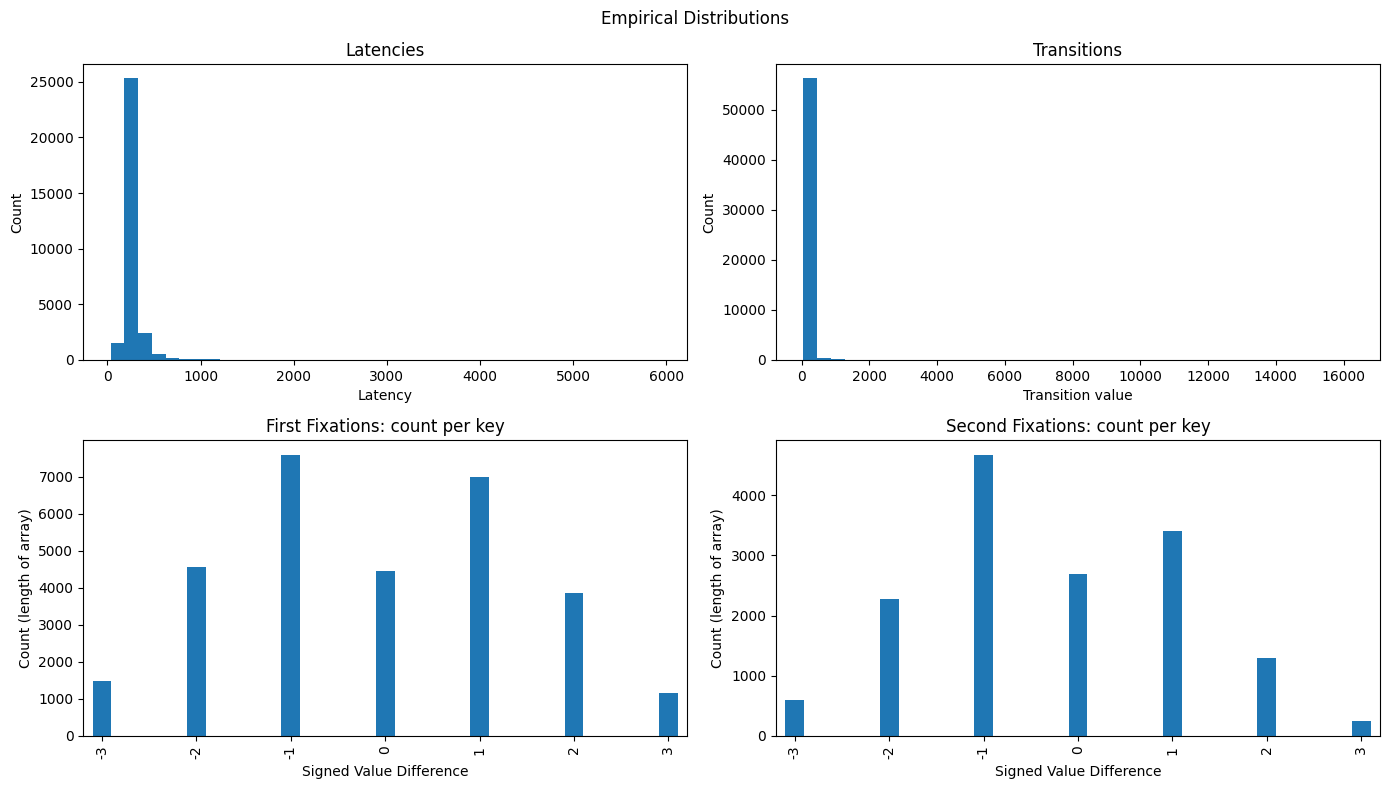

In [24]:
fig, axes = plot_empirical_distributions(empirical_distributions, tick_every=1)
plt.show()

There are some black swan observations in my reconstruction of get_empirical_distributions but they are insanely few in number (2 out of 30k) that adding this feature would not make much of a difference. If it does ever show up in data (fixations longer than 3 seconds), we'll know why, but that is an insane expectation. This is also why I plot histograms of counts and not actual descriptions of the center and spread of fixation durations. This fact will not affect our comparison of the two get_empirical_distributions.

In [25]:
print(sum(list(x < 10 or x > 3000 for x in empirical_distributions['transitions'])))
print(len(empirical_distributions['transitions']))

22
56982


# Creating summary plots from Tavares project data with aDDM_Toolbox

In [26]:
from addm_toolbox.util import *

# trial_conditions_path = os.path.join(parent_dir, "trial_conditions.csv")

# T_trial_conditions_df = load_trial_conditions_from_csv(trial_conditions_path)
T_df = load_data_from_csv(exp_path, fixations_path, convert_item_values)

In [27]:
from addm_toolbox.util import get_empirical_distributions as T_get_empirical_distributions

T_empirical_distributions = T_get_empirical_distributions(T_df)

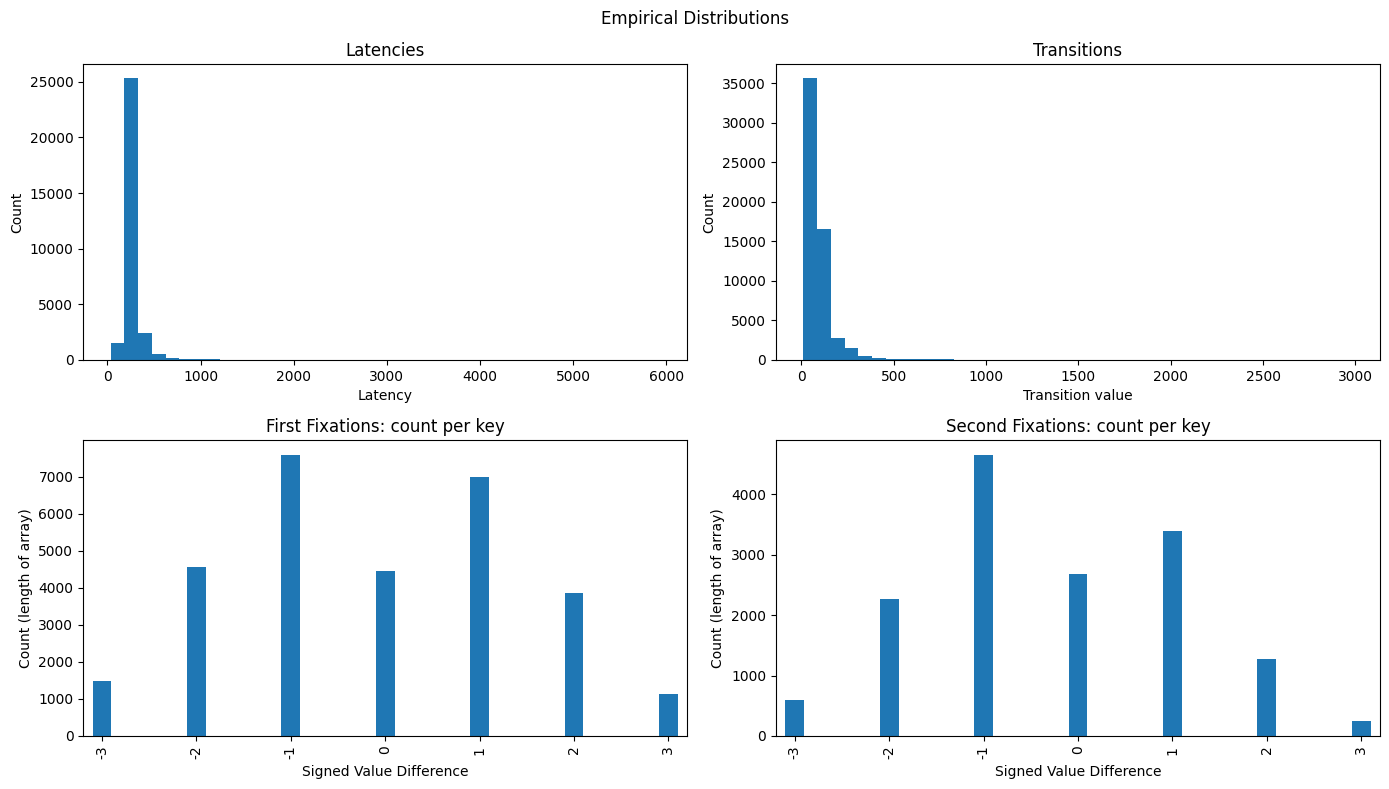

In [28]:
def T_as_1d_float_array(x):
    if x is None:
        return np.array([], dtype=float)
    return np.asarray(x, dtype=float).ravel()

def T_fix_lengths_per_key(fix_map):
    """
    fix_map: dict where keys are floats in [-4.0, 4.0] step 0.25
             and values are array-like (whose lengths we count).
    Returns (keys_sorted_float, lengths_per_key_as_float).
    """
    if not isinstance(fix_map, dict) or not fix_map:
        return np.array([], dtype=float), np.array([], dtype=float)
    # Sort keys numerically to keep the x-axis ordered
    keys = sorted(fix_map.keys(), key=float)
    lengths = [len(_as_1d_float_array(fix_map[k])) for k in keys]
    return np.array(keys, dtype=float), np.array(lengths, dtype=float)

def T_plot_empirical_distributions(ed, *, tick_every=4):
    """
    ed: dict with keys:
        - 'latencies': np.ndarray of floats
        - 'transitions': np.ndarray of floats
        - 'fixations': dict {1: dict{float_key: array}, 2: dict{float_key: array}}

    Creates a 2x2 figure:
      (1,1) histogram of ed['latencies']
      (1,2) histogram of ed['transitions']
      (2,1) bar chart: keys of fixations[1] on x, lengths of arrays as heights
      (2,2) bar chart: keys of fixations[2] on x, lengths of arrays as heights
    """
    latencies = T_as_1d_float_array(np.array(ed.latencies))
    transitions = T_as_1d_float_array(np.array(ed.transitions))

    fix = ed.fixations
    fix1 = fix.get(1, {})
    fix2 = fix.get(2, {})

    keys1, lens1 = T_fix_lengths_per_key(fix1)
    keys2, lens2 = T_fix_lengths_per_key(fix2)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    ax11, ax12, ax21, ax22 = axes.ravel()

    # Top row: true histograms (continuous/binning)
    ax11.hist(latencies, bins=40)
    ax11.set_title("Latencies")
    ax11.set_xlabel("Latency")
    ax11.set_ylabel("Count")

    ax12.hist(transitions, bins=40)
    ax12.set_title("Transitions")
    ax12.set_xlabel("Transition value")
    ax12.set_ylabel("Count")

    # Bottom row: fixed-bin “histograms” → bar charts at the exact key values
    if keys1.size:
        # width smaller than the 0.25 spacing to leave a small gap
        ax21.bar(keys1, lens1, width=0.20, align='center')
        ax21.set_xlim(keys1.min() - 0.2, keys1.max() + 0.2)
        _set_sparse_xticks(ax21, keys1, every=tick_every, rotation=90)
    ax21.set_title("First Fixations: count per key")
    ax21.set_xlabel("Signed Value Difference")
    ax21.set_ylabel("Count (length of array)")

    if keys2.size:
        ax22.bar(keys2, lens2, width=0.20, align='center')
        ax22.set_xlim(keys2.min() - 0.2, keys2.max() + 0.2)
        _set_sparse_xticks(ax22, keys2, every=tick_every, rotation=90)
    ax22.set_title("Second Fixations: count per key")
    ax22.set_xlabel("Signed Value Difference")
    ax22.set_ylabel("Count (length of array)")

    fig.suptitle("Empirical Distributions", y=0.98)
    fig.tight_layout()
    return fig, axes

fig, axes = T_plot_empirical_distributions(T_empirical_distributions, tick_every=1)
plt.show()

If troubleshooting doesn work, find specific trials and debug

## Comparing T_df with total_df

In [29]:
import pandas as pd

# Uses lazy global variable access
def compare_trials_per_parcode(df: pd.DataFrame):
    """
    Print the number of trials for each unique parcode as the dataframe is iterated through.
    """
    assert {'parcode', 'trial'}.issubset(df.columns), "Missing 'parcode' or 'trial' columns."

    # Get unique parcodes
    unique_parcodes = df['parcode'].unique()

    # Iterate and print trial counts
    for par in unique_parcodes:
        n_trials = df.loc[df['parcode'] == par, 'trial'].nunique()
        print(f"Participant {par} difference: {n_trials-len(T_df[str(par)])}")

compare_trials_per_parcode(total_df)

Participant 0 difference: 0
Participant 1 difference: 0
Participant 2 difference: 0
Participant 3 difference: 0
Participant 4 difference: 0
Participant 5 difference: 0
Participant 6 difference: 0
Participant 7 difference: 0
Participant 8 difference: 0
Participant 9 difference: 0
Participant 10 difference: 0
Participant 11 difference: 0
Participant 12 difference: 0
Participant 13 difference: 0
Participant 14 difference: 0
Participant 15 difference: 0
Participant 16 difference: 0
Participant 17 difference: 0
Participant 18 difference: 0
Participant 19 difference: 0
Participant 20 difference: 0
Participant 21 difference: 0
Participant 22 difference: 0
Participant 23 difference: 0
Participant 24 difference: 0


In [30]:
import pandas as pd

# Also uses lazy global access of T_df
def compare_trial_rts(df: pd.DataFrame):
    assert {'parcode', 'trial'}.issubset(df.columns), "Missing 'parcode' or 'trial' columns."

    # Collect (parcode, trial, my_rt, tavares_rt) where they differ
    discrepancies = []

    # Get unique parcodes
    unique_parcodes = df['parcode'].unique()

    for par in unique_parcodes:
        # subset for this participant
        df_par = df[df['parcode'] == par]

        # get unique trials for this participant
        unique_trials = df_par['trial'].unique()

        # nested loop over each trial
        for tr in unique_trials:
            df_trial = df_par[df_par['trial'] == tr]
            my_rt = df_trial['rt'].iloc[0]         # assume one RT per (par, trial)
            tavares_rt = T_df[str(par)][tr].RT        # lazy global access as in your snippet

            if my_rt != tavares_rt:
                discrepancies.append((par, tr, my_rt, tavares_rt))

    if not discrepancies:
        print("All RTs match between df and T_df for every (parcode, trial).")
        return None

    # Return a simple DataFrame of mismatches
    return pd.DataFrame(discrepancies, columns=["parcode", "trial", "df_RT", "Tavares_RT"])

compare_trial_rts(total_df)

All RTs match between df and T_df for every (parcode, trial).


In [75]:
my_arr = T_empirical_distributions.transitions[:56982]==empirical_distributions['transitions']

def first_false(arr: np.ndarray) -> int | None:
    """Return the first index where arr is False, or None if all are True."""
    idx = np.flatnonzero(~arr)
    return int(idx[0]) if idx.size > 0 else None

first_false(my_arr)

353

In [ ]:
fix_df = pd.read_csv('/Users/braydenchien/Desktop/Enkavilab/aDDM-Toolbox/addm_toolbox/data/fixations.csv') 
fix_df = fix_df.loc[fix_df['fix_item']==0] 
fix_df = fix_df.loc[~(fix_df.diff()['trial']==1)] 

,parcode,trial,fix_item,fix_time
1,0,0,0,42.0
3,0,0,0,72.0
5,0,0,0,68.0
10,0,1,0,78.0
12,0,1,0,72.0


In [68]:
def get_consecutive_subsection_fuzzy(
    df: pd.DataFrame,
    col: str,
    pattern: np.ndarray,
    *,
    max_gap: int = 1,   # max number of non-matching (ghost) rows allowed between pattern elements
    tol: float = 0.0    # numeric tolerance for float comparisons
) -> pd.DataFrame:
    """
    Return the first minimal subsection where `pattern` appears in order in column `col`,
    allowing up to `max_gap` intervening (ghost) rows between successive matches,
    and numeric tolerance `tol` for matching.

    Example: with max_gap=1, pattern [a,b,c] can match rows like [a, X, b, c] or [a, b, X, c].
    """
    vals = df[col].to_numpy()
    n = len(pattern)
    m = len(vals)
    if n == 0 or m == 0:
        return pd.DataFrame(columns=df.columns)

    # helper for (tolerant) equality
    def eq(x, y):
        if tol == 0:
            return x == y
        # handle NaNs safely too
        return (np.isfinite(x) & np.isfinite(y) & (np.abs(x - y) <= tol)) or (np.isnan(x) and np.isnan(y))

    for start in range(m):
        # find first match at or after `start`
        if not eq(vals[start], pattern[0]):
            continue

        prev_idx = start
        ok = True
        # match the rest, each within max_gap ghost rows after prev_idx
        for j in range(1, n):
            # next match must be at index in (prev_idx+1 ... prev_idx+1+max_gap)
            hi = min(m - 1, prev_idx + 1 + max_gap)
            match_idx = -1
            for k in range(prev_idx + 1, hi + 1):
                if eq(vals[k], pattern[j]):
                    match_idx = k
                    break
            if match_idx == -1:
                ok = False
                break
            prev_idx = match_idx

        if ok:
            # minimal slice from first match (start) through the last matched index (prev_idx)
            return df.iloc[start:prev_idx + 1]

    # no fuzzy match found
    return pd.DataFrame(columns=df.columns)

In [86]:
get_consecutive_subsection_fuzzy(
    fix_df, 'fix_time',
    T_empirical_distributions.transitions[349:354],
    max_gap=1,
    tol=1e-6
)

,parcode,trial,fix_item,fix_time
1296,0,191,0,286.0
1301,0,192,0,80.0
1303,0,192,0,78.0
1308,0,193,0,76.0
1310,0,193,0,52.0


In [87]:
print(T_empirical_distributions.transitions[349:354])
print(empirical_distributions['transitions'][349:354])

[286.  80.  78.  76.  52.]
[286.  80.  78.  76. 152.]
